# Loan Default Prediction for Credit Risk Assessment

**Project:** Loan Default Risk Prediction - Banking Domain  
**Client:** XYZ Bank | **Sponsor:** Chief Risk Officer

### Objectives
- Identify high-risk customers before loan approval
- Improve data-driven decision-making vs. rule-based systems
- Reduce default rates and protect profitability

### Expected Insights
1. Key factors influencing loan default
2. Risk segmentation of customers
3. Probability of default prediction
4. Threshold recommendation for loan approval

---


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

# Plotting defaults
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)


In [87]:
df = pd.read_csv("Loan_default.csv")

In [88]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [90]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [91]:
df.shape

(255347, 18)

Remove LoanID

Why?

LoanID is unique for every customer

It does not help prediction

It may introduce noise

In [92]:
df.drop("LoanID", axis=1, inplace=True)

## Feature Engineering

Create banking-relevant derived features **before** encoding to capture repayment capacity and credit stress signals.

In [93]:
# Loan-to-income: higher values indicate repayment strain
df["LoanToIncomeRatio"] = df["LoanAmount"] / df["Income"].replace(0, np.nan)

# Estimated monthly payment burden
df["MonthlyPaymentEst"] = (df["LoanAmount"] / df["LoanTerm"]) * (1 + df["InterestRate"] / 100)

# Binary risk flags (created before label encoding)
df["CreditRiskFlag"] = (df["CreditScore"] < 600).astype(int)
df["HighDTIFlag"] = (df["DTIRatio"] > 0.5).astype(int)
df["UnemployedFlag"] = (df["EmploymentType"] == "Unemployed").astype(int)
df["ShortEmploymentFlag"] = (df["MonthsEmployed"] < 12).astype(int)

# Handle any division edge cases
df["LoanToIncomeRatio"] = df["LoanToIncomeRatio"].fillna(df["LoanToIncomeRatio"].median())

df[["LoanToIncomeRatio", "MonthlyPaymentEst", "CreditRiskFlag", "HighDTIFlag"]].describe()


,LoanToIncomeRatio,MonthlyPaymentEst,CreditRiskFlag,HighDTIFlag
count,255347.000000,255347.000000,255347.000000,255347.000000
mean,2.177480,5499.476373,0.546249,0.493951
std,2.178357,5046.965570,0.497857,0.499964
min,0.033749,86.463953,0.000000,0.000000
25%,0.803628,2083.631161,0.000000,0.000000
50%,1.546720,3999.225183,1.000000,0.000000
75%,2.671744,6960.943768,1.000000,1.000000
max,16.532460,26004.803067,1.000000,1.000000


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Age                  255347 non-null  int64  
 1   Income               255347 non-null  int64  
 2   LoanAmount           255347 non-null  int64  
 3   CreditScore          255347 non-null  int64  
 4   MonthsEmployed       255347 non-null  int64  
 5   NumCreditLines       255347 non-null  int64  
 6   InterestRate         255347 non-null  float64
 7   LoanTerm             255347 non-null  int64  
 8   DTIRatio             255347 non-null  float64
 9   Education            255347 non-null  str    
 10  EmploymentType       255347 non-null  str    
 11  MaritalStatus        255347 non-null  str    
 12  HasMortgage          255347 non-null  str    
 13  HasDependents        255347 non-null  str    
 14  LoanPurpose          255347 non-null  str    
 15  HasCoSigner          255347 

Identify Categorical Columns

In [95]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='str')


Encode Categorical Features

In [96]:
from sklearn.preprocessing import LabelEncoder

In [97]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

joblib.dump(label_encoders, MODELS_DIR / "label_encoders.pkl")


['models\\label_encoders.pkl']

In [98]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,HasDependents,LoanPurpose,HasCoSigner,Default,LoanToIncomeRatio,MonthlyPaymentEst,CreditRiskFlag,HighDTIFlag,UnemployedFlag,ShortEmploymentFlag
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,1,4,1,0,0.588262,1619.205558,1,0,0,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,...,0,4,1,0,2.467481,2173.759400,1,1,0,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,...,1,0,0,1,1.534154,6522.379150,1,0,1,0
3,32,31713,44799,743,0,3,7.07,24,0.23,1,...,0,1,0,0,1.412638,1998.595388,0,0,0,1
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,1,0,0,0,0.447179,202.790602,0,1,1,1


In [99]:
df.isnull().sum()

Age                    0
Income                 0
LoanAmount             0
CreditScore            0
MonthsEmployed         0
NumCreditLines         0
InterestRate           0
LoanTerm               0
DTIRatio               0
Education              0
EmploymentType         0
MaritalStatus          0
HasMortgage            0
HasDependents          0
LoanPurpose            0
HasCoSigner            0
Default                0
LoanToIncomeRatio      0
MonthlyPaymentEst      0
CreditRiskFlag         0
HighDTIFlag            0
UnemployedFlag         0
ShortEmploymentFlag    0
dtype: int64

In [100]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

Percentage Distribution

In [101]:
df["Default"].value_counts(normalize=True) * 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

Visualize Class Imbalance

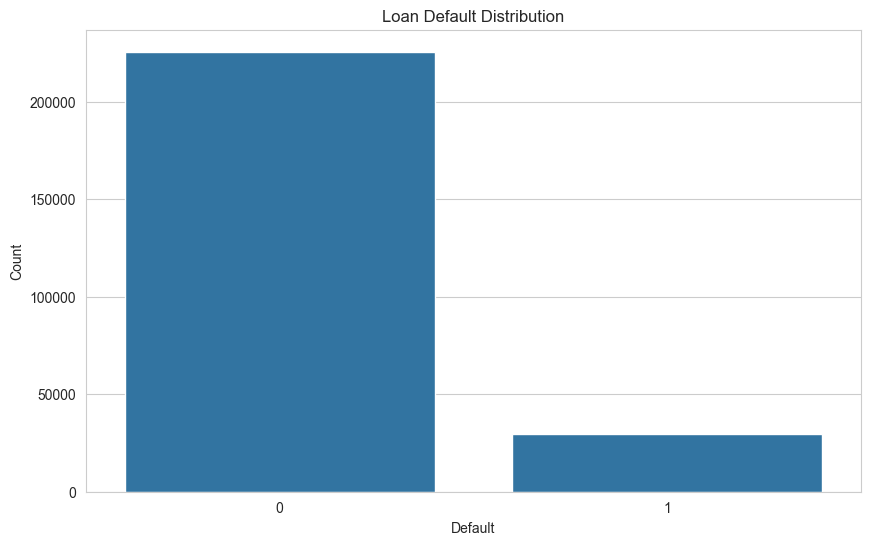

In [102]:
sns.countplot(x='Default', data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Default")
plt.ylabel("Count")

plt.show()

Exploratory Data Analysis (EDA)

Better Visualization Style

Default Distribution Analysis

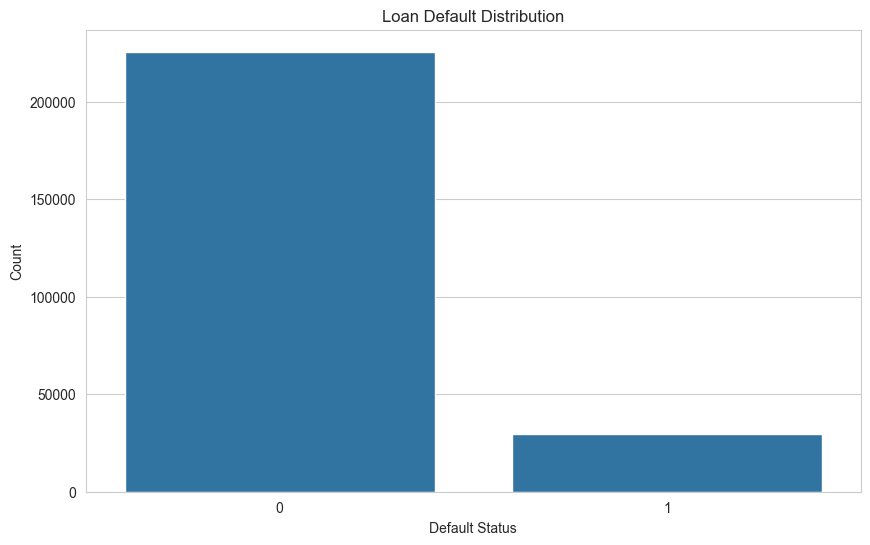

In [103]:
sns.countplot(x='Default', data=df)

plt.title('Loan Default Distribution')
plt.xlabel('Default Status')
plt.ylabel('Count')

plt.show()

The dataset is imbalanced, which reflects real-world banking scenarios where most customers repay loans successfully.

Credit Score vs Default

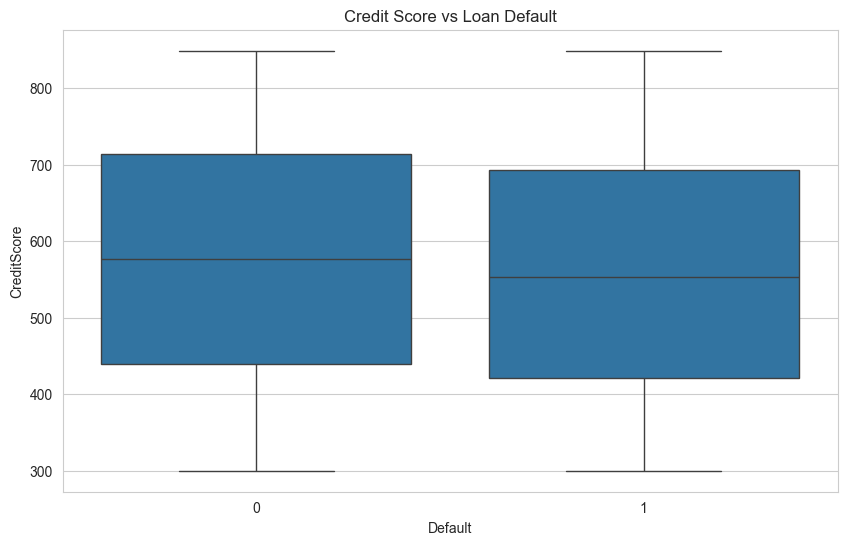

In [104]:
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title("Credit Score vs Loan Default")
plt.show()

Customers with lower credit scores are more likely to default on loans.

Income vs Default

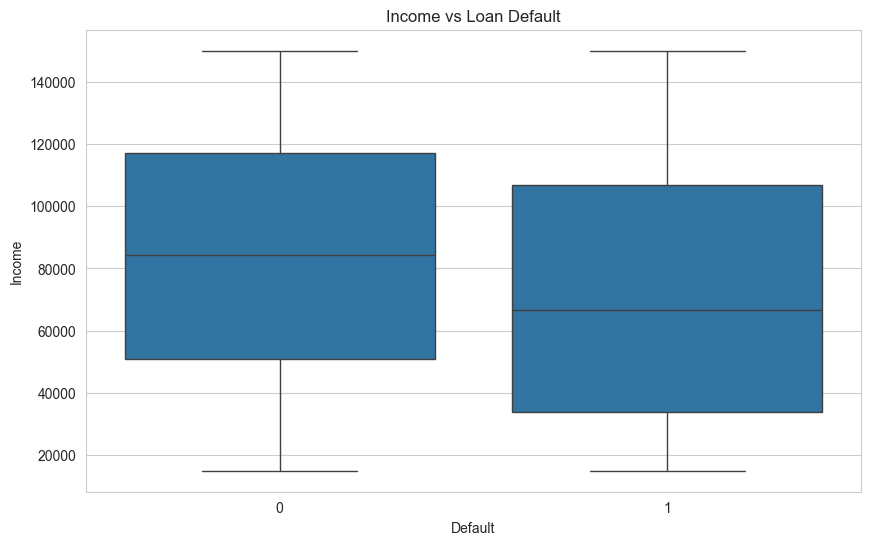

In [105]:
sns.boxplot(x='Default', y='Income', data=df)
plt.title("Income vs Loan Default")
plt.show()

Customers with lower income levels show higher default probability due to weaker repayment capacity.

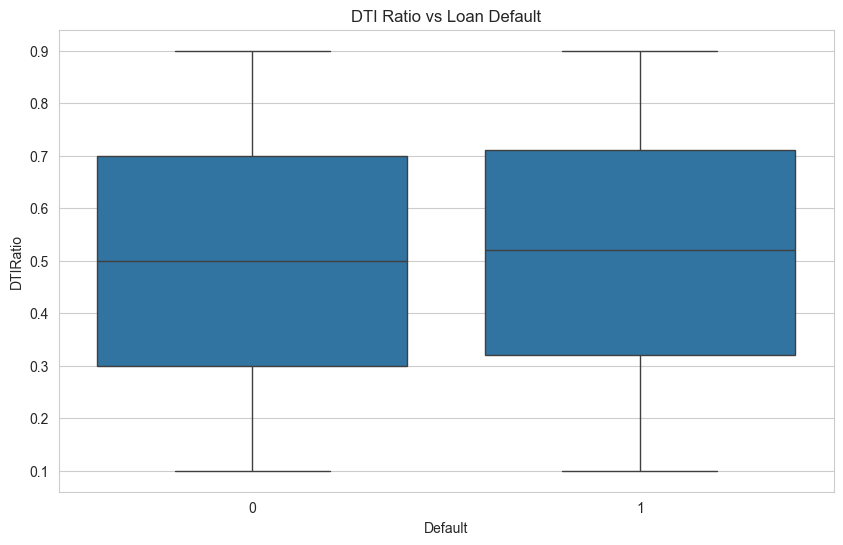

In [106]:
sns.boxplot(x='Default', y='DTIRatio', data=df)

plt.title("DTI Ratio vs Loan Default")

plt.show()

Customers with high debt-to-income ratios are more financially stressed and more likely to default.

Interest Rate vs Default

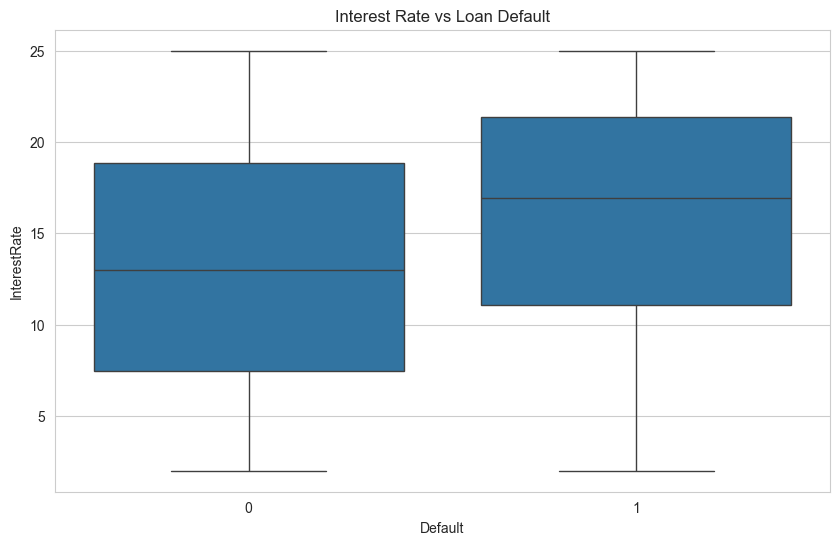

In [107]:
sns.boxplot(x='Default', y='InterestRate', data=df)

plt.title("Interest Rate vs Loan Default")

plt.show()

Loans with higher interest rates show increased probability of default.

Loan Amount vs Default

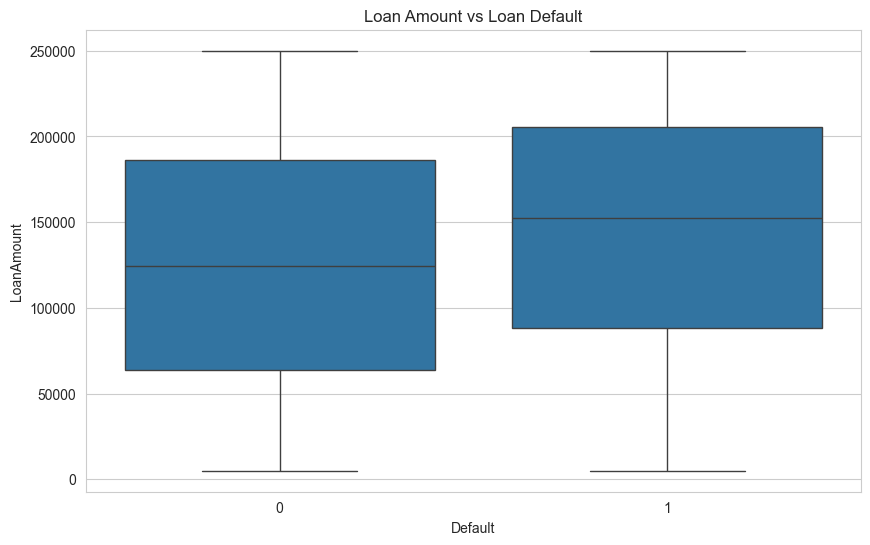

In [108]:
sns.boxplot(x='Default', y='LoanAmount', data=df)

plt.title("Loan Amount vs Loan Default")

plt.show()

Higher loan amounts may increase repayment pressure and default probability.

Employment Stability Analysis

Months Employed vs Default

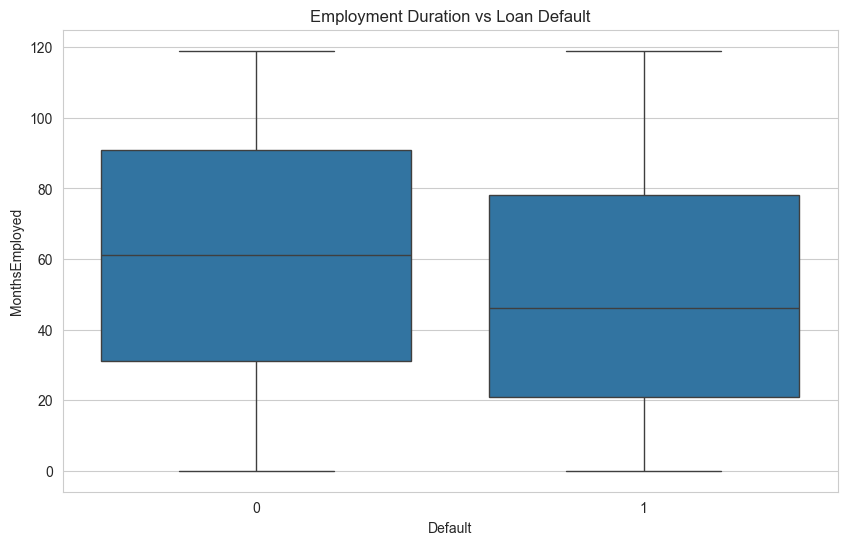

In [109]:
sns.boxplot(x='Default', y='MonthsEmployed', data=df)

plt.title("Employment Duration vs Loan Default")

plt.show()

Employment stability is an important indicator of repayment capability.

Employment Type Risk Analysis

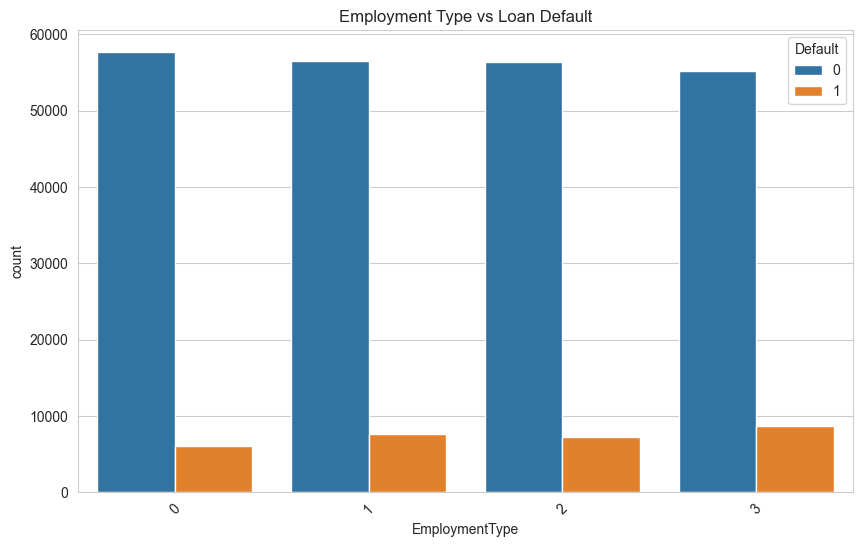

In [110]:
sns.countplot(x='EmploymentType', hue='Default', data=df)

plt.title("Employment Type vs Loan Default")

plt.xticks(rotation=45)

plt.show()

Loan Purpose Risk Analysis

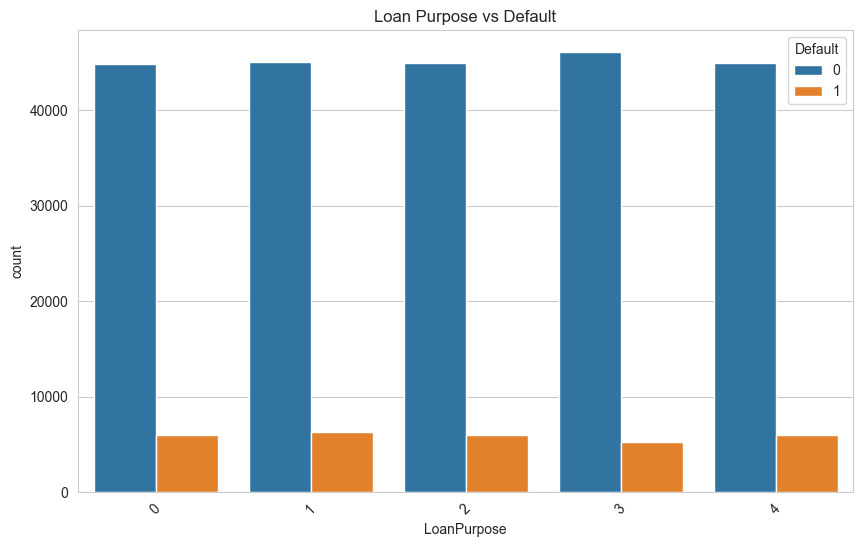

In [111]:
sns.countplot(x='LoanPurpose', hue='Default', data=df)

plt.title("Loan Purpose vs Default")

plt.xticks(rotation=45)

plt.show()

Correlation Heatmap

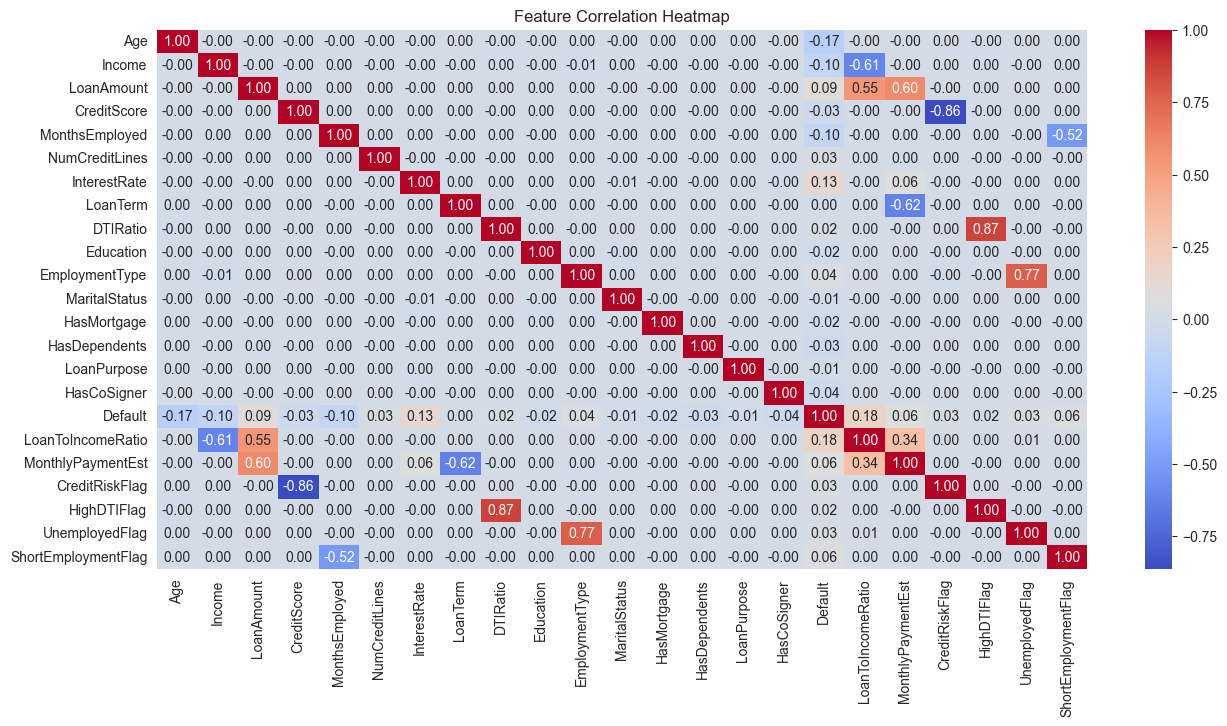

In [112]:
plt.figure(figsize=(15,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

Default Rate by Category

Default Rate by Education

In [113]:
df.groupby('Education')['Default'].mean().sort_values(ascending=False)

Education
1    0.128789
0    0.121011
2    0.108717
3    0.105860
Name: Default, dtype: float64

In [114]:
df.groupby('EmploymentType')['Default'].mean().sort_values(ascending=False)

EmploymentType
3    0.135529
1    0.119652
2    0.114620
0    0.094634
Name: Default, dtype: float64

In [115]:
df.groupby('MaritalStatus')['Default'].mean().sort_values(ascending=False)

MaritalStatus
0    0.125328
2    0.119124
1    0.103972
Name: Default, dtype: float64

In [116]:
df.groupby('LoanPurpose')['Default'].mean().sort_values(ascending=False)

LoanPurpose
1    0.123260
0    0.118814
2    0.118381
4    0.117885
3    0.102348
Name: Default, dtype: float64

Define Features and Target

In [117]:
# Features:
X = df.drop('Default', axis=1)

# Target Column:
y = df['Default']

In [118]:
print(X.shape)
print(y.shape)

(255347, 22)
(255347,)


Train / Validation / Test Split

In [119]:
from sklearn.model_selection import train_test_split

# 70% Train, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split remaining 30% into Validation and Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [120]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (178742, 22)
Validation: (38302, 22)
Test: (38303, 22)


Numerical Columns

In [121]:
numerical_cols = [
    "Age", "Income", "LoanAmount", "CreditScore", "MonthsEmployed",
    "NumCreditLines", "InterestRate", "LoanTerm", "DTIRatio",
    "LoanToIncomeRatio", "MonthlyPaymentEst",
    "CreditRiskFlag", "HighDTIFlag", "UnemployedFlag", "ShortEmploymentFlag",
]


Apply StandardScaler

In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

### Install Dependencies

Run once in terminal: `pip install -r requirements.txt`

Required: scikit-learn, imbalanced-learn, xgboost, pandas, matplotlib, seaborn

Apply SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE helps the model learn default patterns better.

In [123]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [124]:
print(y_train.value_counts())

Default
0    157985
1     20757
Name: count, dtype: int64


In [125]:
print(y_train_smote.value_counts())

Default
0    157985
1    157985
Name: count, dtype: int64


In [126]:
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
print("Scaler saved to models/scaler.pkl")


Scaler saved to models/scaler.pkl


Import Required Libraries

In [127]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [128]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Predict on Validation Data

In [129]:
y_pred_lr = lr_model.predict(X_val_scaled)

y_prob_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

Evaluate Model

In [130]:
# Accuracy
accuracy_score(y_val, y_pred_lr)

0.7183959062189964

In [131]:
# Precision
precision_score(y_val, y_pred_lr, zero_division=0)

0.22840246828933836

In [132]:
# Recall
recall_score(y_val, y_pred_lr)

0.5991456834532374

In [133]:
# ROC-AUC
roc_auc_score(y_val, y_prob_lr)

0.7315100606051461

Full Report

In [134]:
# Full Report
print(classification_report(
    y_val,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       0.93      0.73      0.82     33854
           1       0.23      0.60      0.33      4448

    accuracy                           0.72     38302
   macro avg       0.58      0.67      0.58     38302
weighted avg       0.85      0.72      0.76     38302



In [135]:
# Confusion Matrix
cm = confusion_matrix(
    y_val,
    y_pred_lr
)

print(cm)

[[24851  9003]
 [ 1783  2665]]


ROC Curve

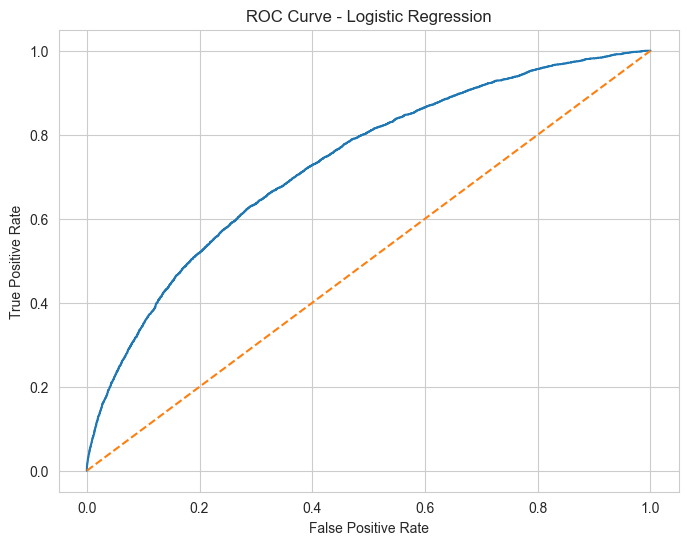

In [136]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_val,
    y_prob_lr
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.show()

In [137]:
results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_val, y_pred_lr),
    "Precision": precision_score(y_val, y_pred_lr, zero_division=0),
    "Recall": recall_score(y_val, y_pred_lr),
    "ROC_AUC": roc_auc_score(y_val, y_prob_lr)
})

Import Random Forest

In [138]:
from sklearn.ensemble import RandomForestClassifier

In [139]:
# Train the Model

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [140]:
# Generate Predictions
y_pred_rf = rf_model.predict(X_val_scaled)

y_prob_rf = rf_model.predict_proba(
    X_val_scaled
)[:,1]

In [141]:
# Evaluate Performance
accuracy_rf = accuracy_score(y_val, y_pred_rf)

print(accuracy_rf)

0.7451569108662733


In [142]:
# Precision
precision_rf = precision_score(y_val, y_pred_rf, zero_division=0)
print(precision_rf)

0.2373183031741323


In [143]:
# Recall
recall_rf = recall_score(
    y_val,
    y_pred_rf
)

print(recall_rf)

0.539568345323741


In [144]:
# ROC-AUC
roc_auc_rf = roc_auc_score(
    y_val,
    y_prob_rf
)

print(roc_auc_rf)

0.724804544472179


In [145]:
# Classification Report
print(
    classification_report(
        y_val,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.93      0.77      0.84     33854
           1       0.24      0.54      0.33      4448

    accuracy                           0.75     38302
   macro avg       0.58      0.66      0.59     38302
weighted avg       0.85      0.75      0.78     38302



In [146]:
# Confusion Matrix
cm_rf = confusion_matrix(
    y_val,
    y_pred_rf
)

print(cm_rf)

[[26141  7713]
 [ 2048  2400]]


In [147]:
# Add Results to Comparison Table
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "ROC_AUC": roc_auc_rf
})

In [148]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Age,0.213769
6,InterestRate,0.117781
13,HasDependents,0.097006
15,HasCoSigner,0.093939
16,LoanToIncomeRatio,0.084915
5,NumCreditLines,0.084694
12,HasMortgage,0.067520
4,MonthsEmployed,0.055348
7,LoanTerm,0.047080
1,Income,0.031484


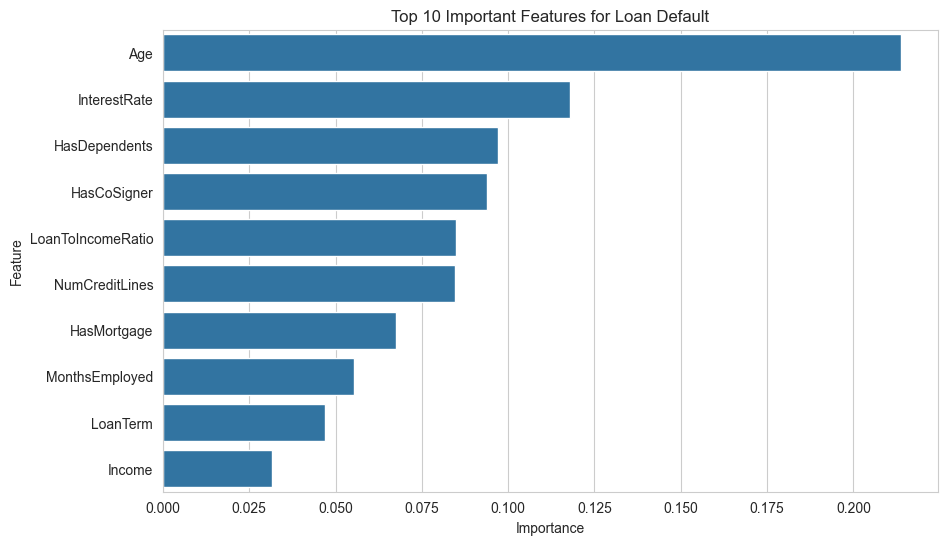

In [149]:
# Visualize Top Features
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features for Loan Default"
)

plt.show()

XGBoost Model

In [150]:
# Import Library

from xgboost import XGBClassifier

In [151]:
# Create XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

In [152]:
# Train the Model
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [153]:
# Generate Predictions
y_pred_xgb = xgb_model.predict(
    X_val_scaled
)

y_prob_xgb = xgb_model.predict_proba(
    X_val_scaled
)[:,1]

In [154]:
# Evaluate XGBoost
accuracy_xgb = accuracy_score(
    y_val,
    y_pred_xgb
)

In [155]:
# Precision
precision_xgb = precision_score(
    y_val,
    y_pred_xgb
)

In [156]:
# Recall
recall_xgb = recall_score(
    y_val,
    y_pred_xgb
)

In [157]:
# ROC-AUC
roc_auc_xgb = roc_auc_score(
    y_val,
    y_prob_xgb
)

In [158]:
# Classification Report
print(
    classification_report(
        y_val,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     33854
           1       0.36      0.23      0.28      4448

    accuracy                           0.86     38302
   macro avg       0.63      0.59      0.60     38302
weighted avg       0.84      0.86      0.85     38302



In [159]:
# Comfusion Matrix
cm_xgb = confusion_matrix(
    y_val,
    y_pred_xgb
)
print(cm_xgb)

[[31988  1866]
 [ 3417  1031]]


In [160]:
# Add Results to Comparison Table
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_xgb,
    "Precision": precision_xgb,
    "Recall": recall_xgb,
    "ROC_AUC": roc_auc_xgb
})

In [161]:
# Compare All Models
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,ROC_AUC
0,Logistic Regression,0.718396,0.228402,0.599146,0.731510
2,XGBoost,0.862070,0.355885,0.231790,0.730786
1,Random Forest,0.745157,0.237318,0.539568,0.724805


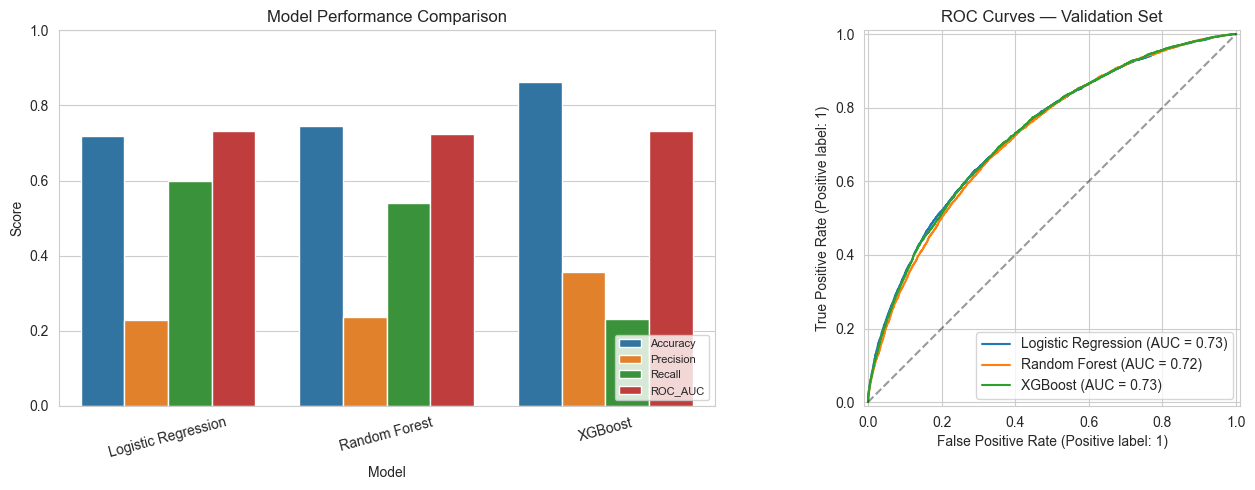

In [162]:
# Visual model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_melt = results_df.melt(
    id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "ROC_AUC"],
    var_name="Metric", value_name="Score"
)
sns.barplot(data=metrics_melt, x="Model", y="Score", hue="Metric", ax=axes[0])
axes[0].set_title("Model Performance Comparison")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(loc="lower right", fontsize=8)

# Combined ROC curves (all 3 models)
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_val, y_prob_lr, name="Logistic Regression", ax=axes[1])
RocCurveDisplay.from_predictions(y_val, y_prob_rf, name="Random Forest", ax=axes[1])
RocCurveDisplay.from_predictions(y_val, y_prob_xgb, name="XGBoost", ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("ROC Curves — Validation Set")
plt.tight_layout()
plt.show()


In [163]:
# Threshold optimization — find F1-optimal cutoff on validation set
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.95, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_val, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_val, y_pred_threshold, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold = float(best_row["Threshold"])

print(f"Recommended approval threshold: {best_threshold:.2f}")
print(f"  Precision: {best_row['Precision']:.3f} | Recall: {best_row['Recall']:.3f} | F1: {best_row['F1']:.3f}")
threshold_df


Recommended approval threshold: 0.35
  Precision: 0.279 | Recall: 0.447 | F1: 0.343


,Threshold,Precision,Recall,F1
0,0.05,0.129108,0.974146,0.227999
1,0.10,0.152407,0.891862,0.260327
2,0.15,0.176625,0.801484,0.289461
3,0.20,0.201106,0.703237,0.312769
4,0.25,0.224731,0.610836,0.328577
5,0.30,0.248635,0.522032,0.336839
6,0.35,0.278610,0.447167,0.343316
7,0.40,0.302162,0.367581,0.331677
8,0.45,0.328589,0.295863,0.311369
9,0.50,0.355885,0.231790,0.280735


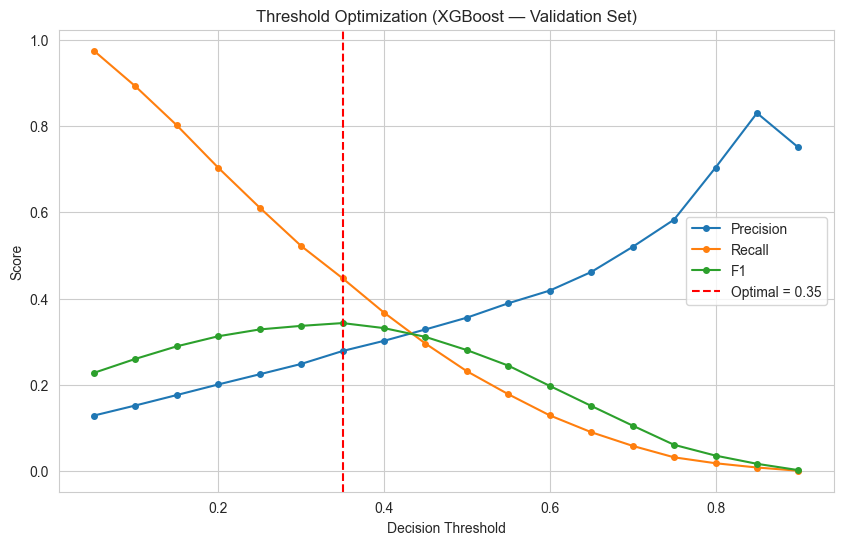

In [164]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision", marker="o", ms=4)
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall", marker="o", ms=4)
plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1", marker="o", ms=4)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Optimal = {best_threshold:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization (XGBoost — Validation Set)")
plt.legend()
plt.show()


In [165]:
# Apply optimal threshold on validation set
y_pred_optimal = (y_prob_xgb >= best_threshold).astype(int)

print("Validation metrics at optimal threshold:")
print(f"  Accuracy:  {accuracy_score(y_val, y_pred_optimal):.4f}")
print(f"  Precision: {precision_score(y_val, y_pred_optimal, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_val, y_pred_optimal):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_val, y_prob_xgb):.4f}")
print(classification_report(y_val, y_pred_optimal, target_names=["No Default", "Default"]))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_optimal))


Validation metrics at optimal threshold:
  Accuracy:  0.8013
  Precision: 0.2786
  Recall:    0.4472
  ROC-AUC:   0.7308
              precision    recall  f1-score   support

  No Default       0.92      0.85      0.88     33854
     Default       0.28      0.45      0.34      4448

    accuracy                           0.80     38302
   macro avg       0.60      0.65      0.61     38302
weighted avg       0.85      0.80      0.82     38302

Confusion Matrix:
[[28704  5150]
 [ 2459  1989]]


## Final Test Set Evaluation

Unseen 15% holdout — no tuning was done on this split.

In [166]:
test_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

print("=== TEST SET RESULTS (XGBoost) ===")
print(f"Threshold used: {best_threshold:.2f}")
print(f"Accuracy:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision: {precision_score(y_test, test_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, test_prob):.4f}")
print(classification_report(y_test, test_pred, target_names=["No Default", "Default"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_pred))


=== TEST SET RESULTS (XGBoost) ===
Threshold used: 0.35
Accuracy:  0.8004
Precision: 0.2780
Recall:    0.4501
ROC-AUC:   0.7356
              precision    recall  f1-score   support

  No Default       0.92      0.85      0.88     33855
     Default       0.28      0.45      0.34      4448

    accuracy                           0.80     38303
   macro avg       0.60      0.65      0.61     38303
weighted avg       0.85      0.80      0.82     38303

Confusion Matrix:
[[28656  5199]
 [ 2446  2002]]


## Risk-Based Customer Categorization

In [167]:
def risk_segment(prob, low_cutoff=None, high_cutoff=0.70):
    """Segment customers into Low / Medium / High default risk."""
    low_cutoff = low_cutoff if low_cutoff is not None else best_threshold
    if prob < low_cutoff:
        return "Low Risk"
    elif prob < high_cutoff:
        return "Medium Risk"
    return "High Risk"


Risk Segment Validation (Test Set):
               Count  Avg_Prob  Actual_Default_Rate
Risk_Category                                      
Low Risk       31102  0.143053                 7.86
Medium Risk     6701  0.475445                26.06
High Risk        500  0.764674                51.20


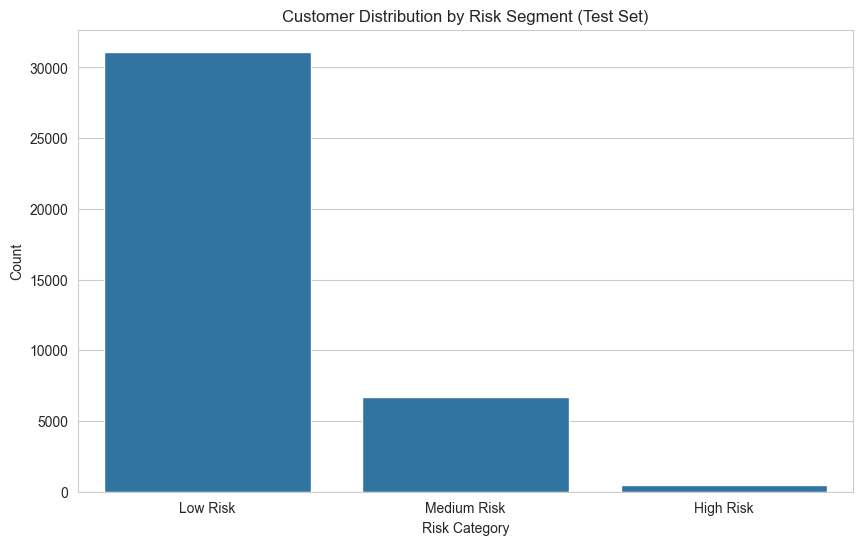

In [168]:
risk_df = pd.DataFrame({
    "Default_Probability": test_prob,
    "Actual_Default": y_test.values,
    "Predicted_Default": test_pred,
})
risk_df["Risk_Category"] = risk_df["Default_Probability"].apply(risk_segment)

# Validate segments: actual default rate should increase with risk tier
segment_summary = (
    risk_df.groupby("Risk_Category")
    .agg(
        Count=("Actual_Default", "count"),
        Avg_Prob=("Default_Probability", "mean"),
        Actual_Default_Rate=("Actual_Default", "mean"),
    )
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)
segment_summary["Actual_Default_Rate"] = (segment_summary["Actual_Default_Rate"] * 100).round(2)
print("Risk Segment Validation (Test Set):")
print(segment_summary)

sns.countplot(data=risk_df, x="Risk_Category", order=["Low Risk", "Medium Risk", "High Risk"])
plt.title("Customer Distribution by Risk Segment (Test Set)")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.show()


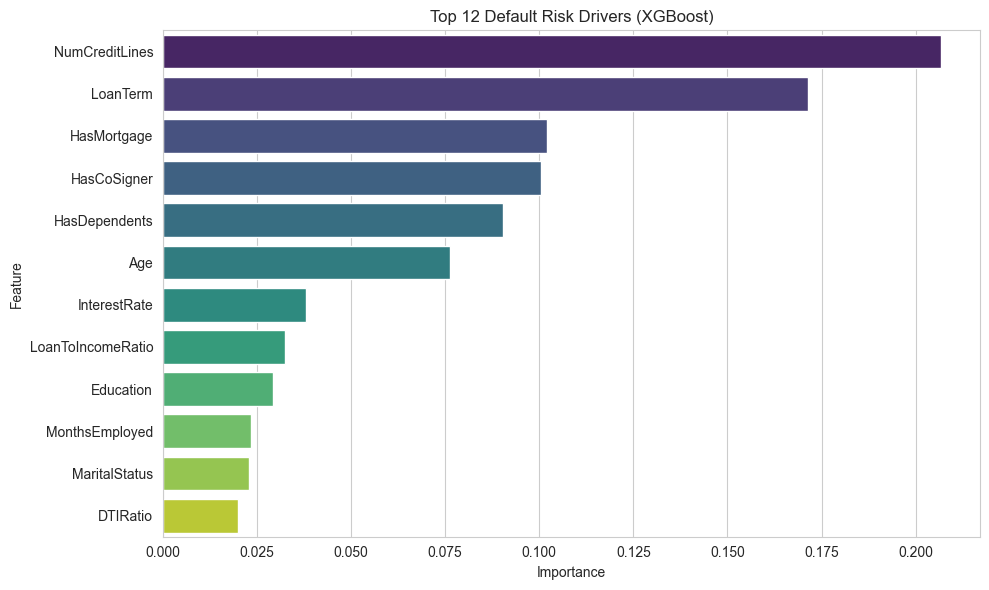

Top 5 risk drivers:
  • NumCreditLines: 0.2068
  • LoanTerm: 0.1713
  • HasMortgage: 0.1021
  • HasCoSigner: 0.1006
  • HasDependents: 0.0903


In [169]:
# XGBoost feature importance (final model)
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance.head(12), x="Importance", y="Feature", palette="viridis")
plt.title("Top 12 Default Risk Drivers (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 5 risk drivers:")
for _, row in xgb_importance.head(5).iterrows():
    print(f"  • {row['Feature']}: {row['Importance']:.4f}")


In [170]:
# Persist production artifacts
joblib.dump(xgb_model, MODELS_DIR / "xgb_model.pkl")
joblib.dump({
    "best_threshold": best_threshold,
    "feature_columns": list(X.columns),
    "numerical_cols": numerical_cols,
    "risk_low_cutoff": best_threshold,
    "risk_high_cutoff": 0.70,
}, MODELS_DIR / "model_config.pkl")

print("Saved: models/xgb_model.pkl, models/model_config.pkl")


Saved: models/xgb_model.pkl, models/model_config.pkl


## Business Recommendations for XYZ Bank

Based on model results, feature importance, and risk segmentation:

### 1. Loan Approval Policy
| Risk Segment | Default Probability | Recommended Action |
|--------------|--------------------|--------------------|
| **Low Risk** | Below optimal threshold | **Auto-approve** with standard terms; fast-track processing |
| **Medium Risk** | Threshold to 70% | **Manual review** — verify income docs, consider co-signer or lower amount |
| **High Risk** | Above 70% | **Decline or restructure** — higher down payment, shorter term, or secured collateral |

### 2. Key Risk Drivers to Monitor
Prioritize these in underwriting rules and periodic portfolio reviews:
- **Credit Score** and **DTI Ratio** — strongest numeric predictors
- **Employment status** — unemployed applicants show materially higher default rates
- **Loan-to-Income Ratio** — flag applications where loan exceeds ~40% of annual income
- **Interest Rate** — higher-rate loans correlate with elevated default risk

### 3. Threshold Strategy
- Use the **F1-optimal threshold** (data-driven from validation) as the primary approve/decline cutoff
- Tune threshold by business objective:
  - **Lower threshold** → catch more defaults (higher recall), but more good customers rejected
  - **Higher threshold** → approve more loans (higher precision on flagged defaults), but miss risky borrowers

### 4. Expected Business Impact
- Replace pure rule-based screening with **probability scores** for every application
- Target **high-risk segment** for enhanced due diligence before disbursement
- Monitor segment default rates monthly; recalibrate threshold if portfolio mix shifts
- Retrain model quarterly with new loan performance data

### 5. Next Steps for Production
1. Deploy saved model (`models/xgb_model.pkl`) into loan origination API
2. A/B test model-assisted vs. rule-only decisions for 90 days
3. Track KPIs: default rate, approval rate, revenue per approved loan
4. Add SHAP explanations for regulatory transparency (fair lending audits)
